# Project Visuals for Midterm Presentations

In [1]:
##Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import kagglehub
import plotly.express as px

## CO2 Emissions
- GHG emissions include CO2 (fossil only), CH4, N2O and F-gases

In [3]:
df_CO2 = pd.read_excel("Data/EDGAR_2025_GHG_booklet_2025.xlsx" , sheet_name='GHG_per_capita_by_country', nrows=210)
# print(df_CO2.head())
# print(df_CO2.columns.tolist())

df_CO2.rename(columns={'EDGAR Country Code': 'CountryCode'}, inplace=True)

print(df_CO2.columns.tolist())
# Reshape from wide to long
# Get all columns that are NOT 'CountryCode' or 'Country' (these are the year columns)
year_columns = [col for col in df_CO2.columns if col not in ['CountryCode', 'Country']]

# First, convert the year columns to numeric
for col in year_columns:
    df_CO2[col] = pd.to_numeric(df_CO2[col], errors='coerce')

# Melt using column positions
df_long = df_CO2.melt(id_vars=[df_CO2.columns[0], df_CO2.columns[1]], 
                       var_name='Year', 
                       value_name='GHG Emissions Per Capita')

# Convert Year to numeric
df_long['Year'] = pd.to_numeric(df_long['Year'])

# Remove rows with NaN emissions
df_long = df_long.dropna(subset=['GHG Emissions Per Capita'])

# Rename the first two columns
df_long = df_long.rename(columns={
    df_long.columns[0]: 'CountryCode',
    df_long.columns[1]: 'Country'
})

print(df_long.head())


['CountryCode', 'Country', 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  CountryCode      Country  Year  GHG Emissions Per Capita
0         ABW        Aruba  1970                  0.625934
1         AFG  Afghanistan  1970                  1.375142
2         AGO       Angola  1970                  2.779412
3         AIA     Anguilla  1970                  0.530614
4         ALB      Albania  1970                  3.827258


Countries of most importance from Bernard's list

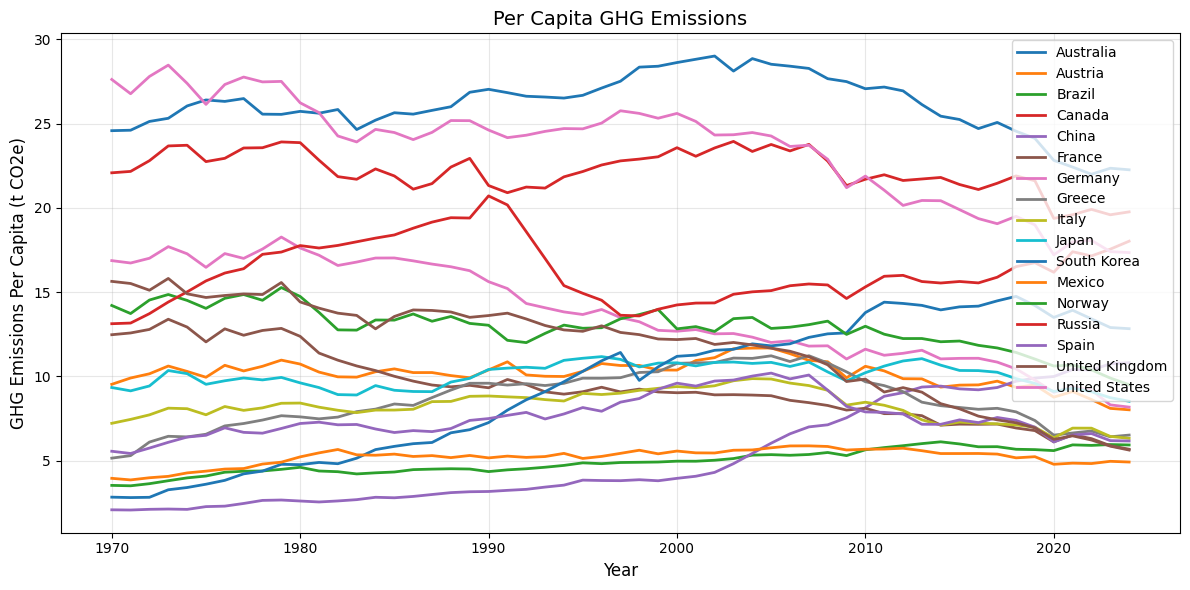

In [4]:
countries = [
    'Australia', 'Austria', 'Brazil', 'Canada', 
    'China', 'France', 'Germany', 
    'Greece', 'Italy', 'Japan', 'South Korea', 
    'Mexico', 'Norway', 'Russia', 'Spain', 
    'United Kingdom', 'United States'
]

filtered_df = df_long[df_long['Country'].isin(countries)]

# Simple per capita plot
pivot_percapita = filtered_df.pivot(index='Year', columns='Country', values='GHG Emissions Per Capita')

fig, ax = plt.subplots(figsize=(12, 6))

for country in countries:
    pivot_percapita[country].plot(ax=ax, linewidth=2, label=country)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('GHG Emissions Per Capita (t CO2e)', fontsize=12)
ax.set_title('Per Capita GHG Emissions', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Version 2

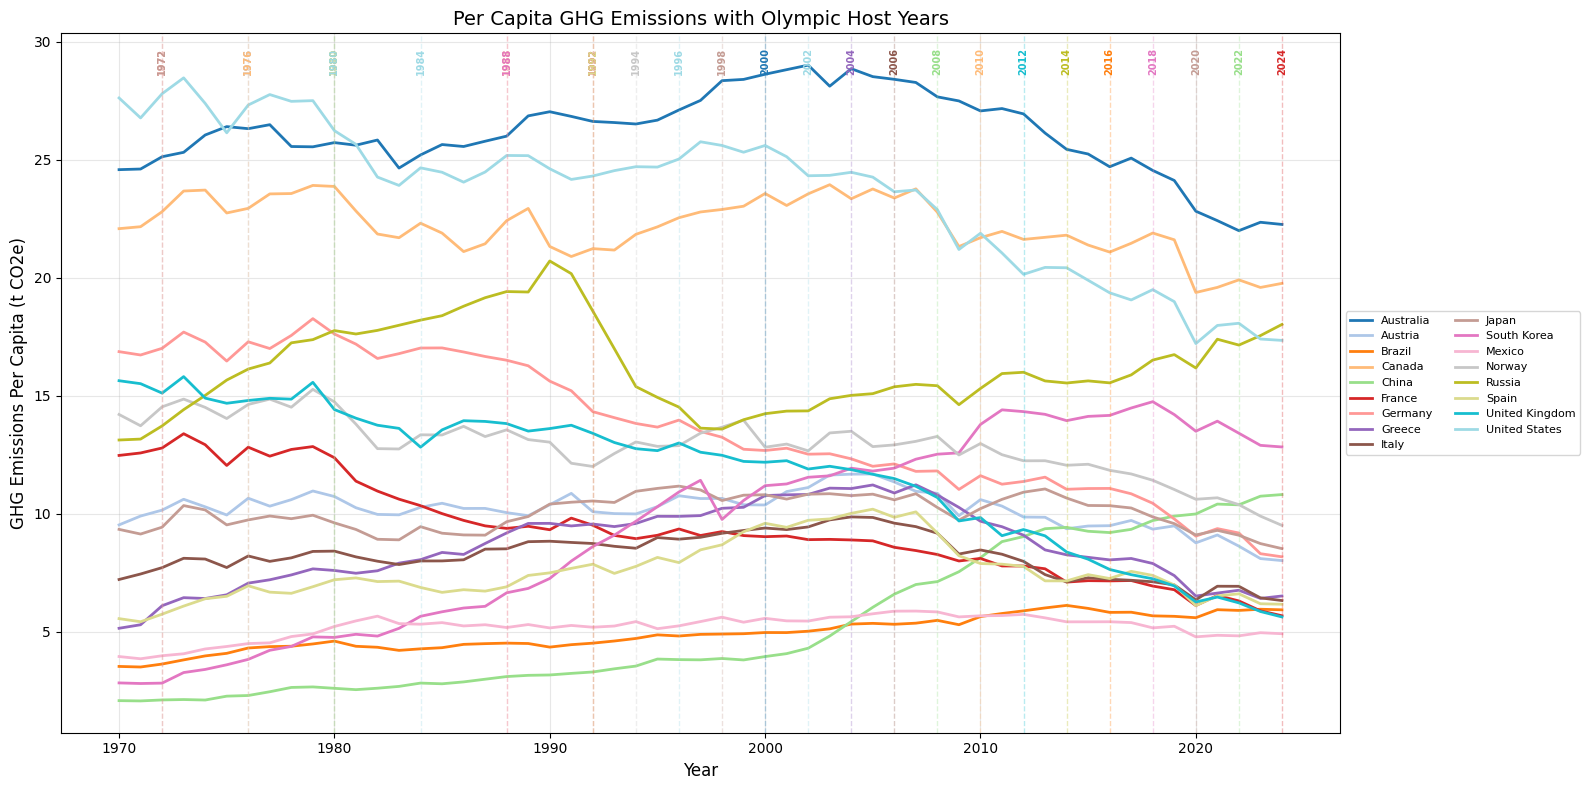

In [7]:

countries = [
    'Australia', 'Austria', 'Brazil', 'Canada', 
    'China', 'France', 'Germany', 
    'Greece', 'Italy', 'Japan', 'South Korea', 
    'Mexico', 'Norway', 'Russia', 'Spain', 
    'United Kingdom', 'United States'
]

filtered_df = df_long[df_long['Country'].isin(countries)]

# Simple per capita plot
pivot_percapita = filtered_df.pivot(index='Year', columns='Country', values='GHG Emissions Per Capita')

# Define colors for each country (using a colormap)
import matplotlib.cm as cm
import numpy as np

# Create a color map
colors = cm.tab20(np.linspace(0, 1, len(countries)))
color_map = {country: colors[i] for i, country in enumerate(countries)}

# Olympics hosted by each country with years
olympics = {
    'Australia': [1956, 2000],  # Melbourne, Sydney
    'Austria': [1964, 1976],    # Innsbruck x2
    'Brazil': [2016],           # Rio de Janeiro
    'Canada': [1976, 1988, 2010],  # Montreal, Calgary, Vancouver
    'China': [2008, 2022],      # Beijing x2
    'France': [1900, 1924, 1968, 1992, 2024],  # Paris x2, Chamonix, Grenoble, Albertville
    'Germany': [1936, 1972],    # Berlin, Munich (plus 1936 Garmisch-Partenkirchen)
    'Greece': [1896, 2004],     # Athens x2
    'Italy': [1956, 1960, 2006, 2026],  # Cortina, Rome, Turin, Milan-Cortina
    'Japan': [1964, 1972, 1998, 2020],  # Tokyo x2, Sapporo, Nagano
    'South Korea': [1988, 2018],  # Seoul, PyeongChang
    'Mexico': [1968],           # Mexico City
    'Norway': [1952, 1994],     # Oslo, Lillehammer
    'Russia': [1980, 2014],     # Moscow, Sochi (as USSR and Russia)
    'Spain': [1992],            # Barcelona
    'United Kingdom': [1908, 1948, 2012],  # London x3
    'United States': [1932, 1960, 1980, 1984, 1996, 2002]  # Lake Placid x2, Squaw Valley, LA x2, Atlanta, Salt Lake
}

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

for country in countries:
    if country in pivot_percapita.columns:
        pivot_percapita[country].plot(ax=ax, linewidth=2, 
                                       color=color_map[country], label=country)

# Add vertical lines for Olympics
for country, years in olympics.items():
    if country in color_map:
        color = color_map[country]
        for year in years:
            if year in pivot_percapita.index:
                ax.axvline(x=year, color=color, linestyle='--', alpha=0.3, linewidth=1)
                # Add label above the line
                ax.text(year, ax.get_ylim()[1] * 0.98, f'{year}', 
                       ha='center', va='top', color=color, fontsize=7, fontweight='bold', rotation=90)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('GHG Emissions Per Capita (t CO2e)', fontsize=12)
ax.set_title('Per Capita GHG Emissions with Olympic Host Years', fontsize=14)
ax.grid(True, alpha=0.3)

# Move legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

Zoom In on 3 - Example

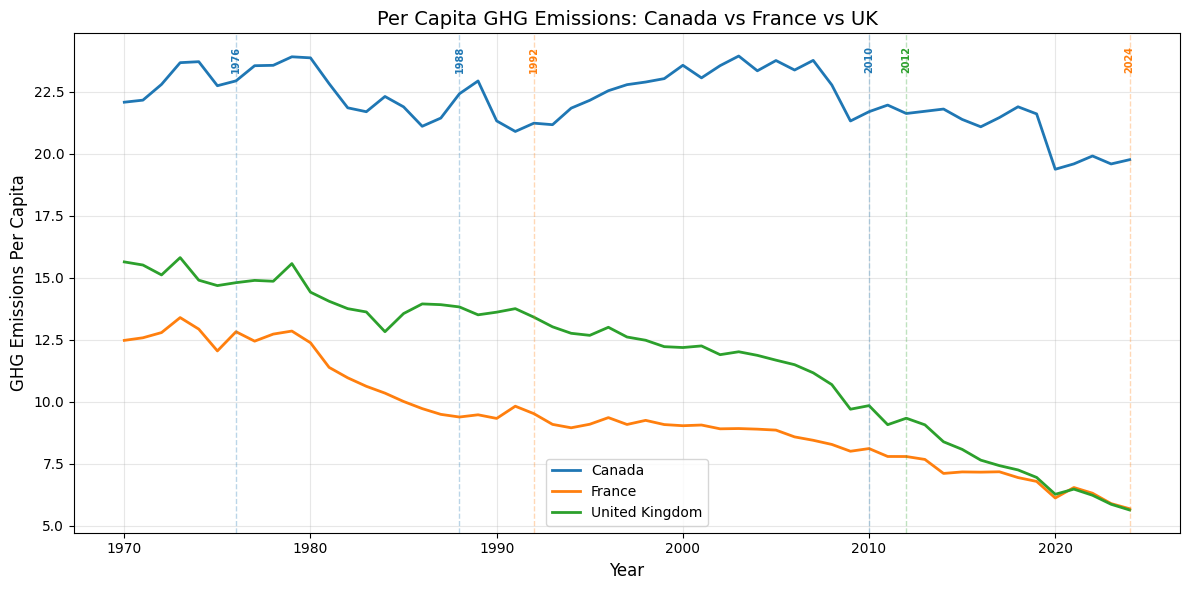

In [15]:
pivot_percapita = filtered_df.pivot(index='Year', columns='Country', values='GHG Emissions Per Capita')
countries = ['Canada', 'France', 'United Kingdom'] 
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the lines and store the color
color_map = {}
for country in countries:
    line = ax.plot(pivot_percapita.index, pivot_percapita[country], linewidth=2, label=country)[0]
    color_map[country] = line.get_color()  # Get the color from the line object

#  vertical lines using the same colors
for country, years in olympics.items():
    if country in countries:  # Only process selected countries
        color = color_map[country]  # Use the color from the line plot
        for year in years:
            if year in pivot_percapita.index:
                ax.axvline(x=year, color=color, linestyle='--', alpha=0.3, linewidth=1)
                #Add label above theline
                ax.text(year, ax.get_ylim()[1] * 0.98, f'{year}', 
                       ha='center', va='top', color=color, fontsize=7, fontweight='bold', rotation=90)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('GHG Emissions Per Capita', fontsize=12)
ax.set_title('Per Capita GHG Emissions: Canada vs France vs UK', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

London (2012) - homelessness xlxs or T87_EqlYvkV.csv
https://data.london.gov.uk/dataset/homelessness-provision-borough-24805
France (2024) - https://data.europa.eu/data/datasets/https-opendata-paris-fr-explore-dataset-exclusion-sans-domicilisme-?locale=en


London - PCS PFA
	https://www.gov.uk/government/statistical-data-sets/police-recorded-crime-and-outcomes-open-data-tables#police-recorded-crime-open-data-police-force-area-tables
Paris
https://www.interieur.gouv.fr/Interstats/Datavisualisation/ENGLISH-Welcome-to-the-SSMSI-Data-Visualisation-Space


# worldhappiness.report
- Short falls for measurement
    - only been tracked since 2012
    - only has 

EDA

In [23]:
# WHR26_Data_Figure_2.1

happiness_df= pd.read_excel("Data/WHR26_Data_Figure_2.1.xlsx")
print(happiness_df.head())
happiness_df_2 = happiness_df[['Year','Rank', 'Country name']]
print(happiness_df_2.head())
print(happiness_df_2['Year'].unique())
unique_countries = sorted(happiness_df_2['Country name'].unique())
print(unique_countries)
print(happiness_df.shape)
happiness_df_2.shape

   Year  Rank Country name  Life evaluation (3-year average)  Lower whisker  \
0  2025     1      Finland                             7.764          7.690   
1  2025     2      Iceland                             7.540          7.449   
2  2025     3      Denmark                             7.539          7.446   
3  2025     4   Costa Rica                             7.439          7.356   
4  2025     5       Sweden                             7.255          7.172   

   Upper whisker  Explained by: Log GDP per capita  \
0          7.837                             1.915   
1          7.630                             1.971   
2          7.631                             1.986   
3          7.522                             1.697   
4          7.337                             1.950   

   Explained by: Social support  Explained by: Healthy life expectancy  \
0                         1.638                                  0.939   
1                         1.720                     

(2116, 3)

Plotting all of the Countries

Available countries: ['Australia', 'Austria', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'Greece', 'Italy', 'Japan', 'Republic of Korea', 'Mexico', 'Norway', 'Spain', 'United Kingdom', 'United States']


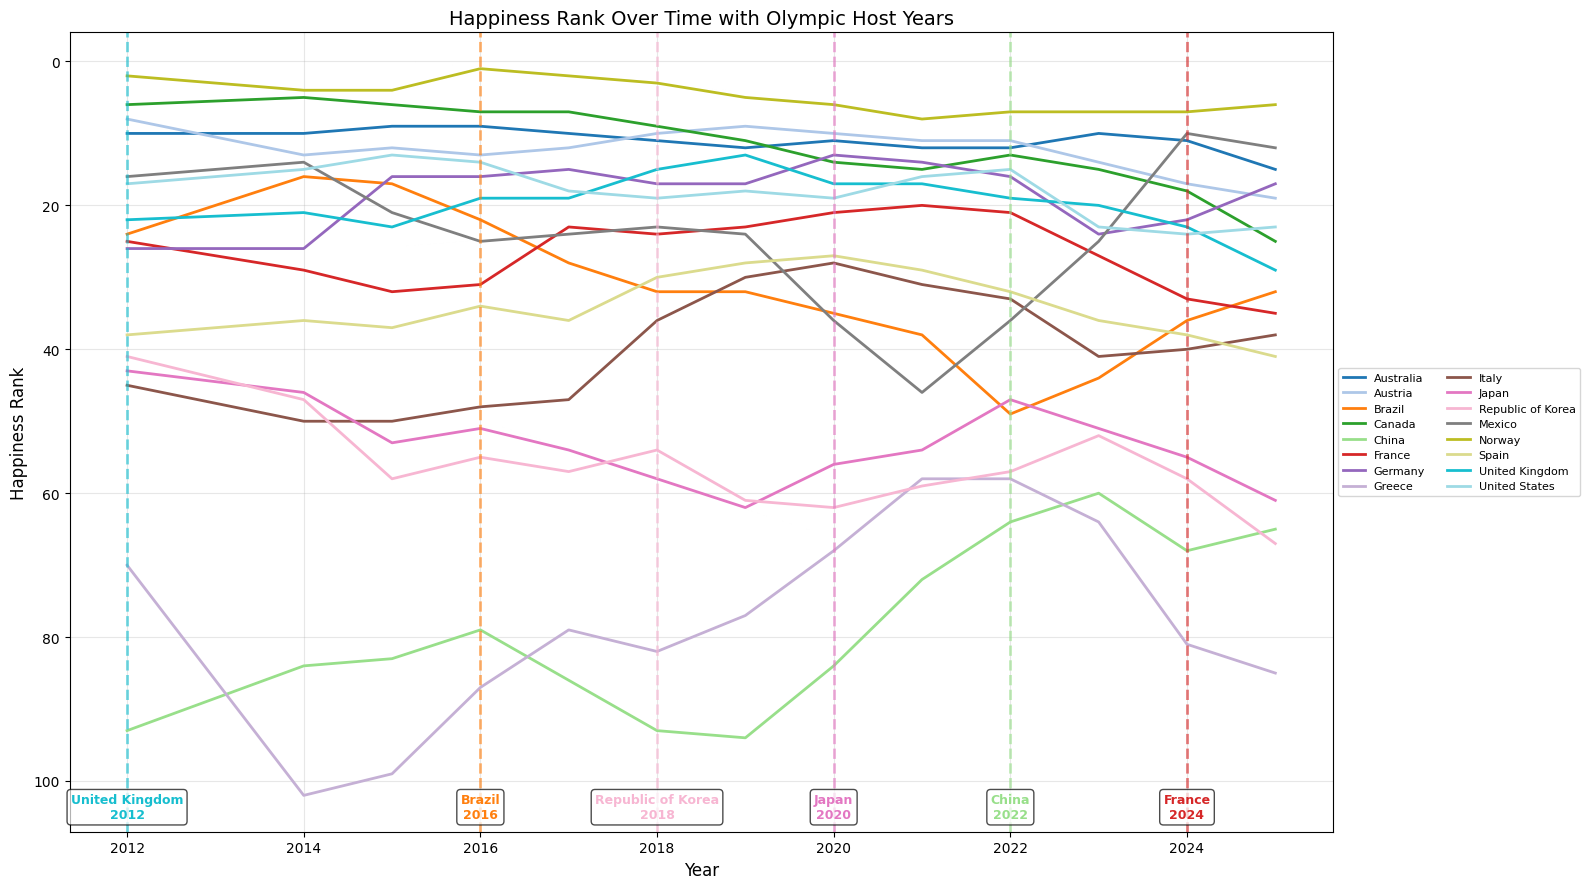

In [27]:
# Filter for selected countries
countries = [
    'Australia', 'Austria', 'Brazil', 'Canada', 
    'China', 'France', 'Germany', 
    'Greece', 'Italy', 'Japan', 'Republic of Korea', 
    'Mexico', 'Norway', 'Russia', 'Spain', 
    'United Kingdom', 'United States'
]

# Check which countries actually exist
available_countries = [c for c in countries if c in happiness_df_2['Country name'].unique()]
print("Available countries:", available_countries)

# Filter the DataFrame
filtered_df = happiness_df_2[happiness_df_2['Country name'].isin(available_countries)]

# Filter for years >= 2012
filtered_df = filtered_df[filtered_df['Year'] >= 2012]

# Pivot the data
pivot_filtered = filtered_df.pivot(index='Year', columns='Country name', values='Rank')

# Create a color map for each country
colors = cm.tab20(np.linspace(0, 1, len(available_countries)))
color_map = {country: colors[i] for i, country in enumerate(available_countries)}

# Olympics hosted by each country with years (only 2012+)
olympics = {
    'Australia': [2000],           # Sydney (outside range, but keep for reference)
    'Austria': [],                 # None since 2012
    'Brazil': [2016],              # Rio de Janeiro
    'Canada': [2010],              # Vancouver (outside range)
    'China': [2022],               # Beijing (only 2022 since 2012)
    'France': [2024],              # Paris
    'Germany': [],                 # None since 2012
    'Greece': [2004],              # Athens (outside range)
    'Italy': [2026],               # Milan-Cortina (future)
    'Japan': [2020],               # Tokyo
    'Republic of Korea': [2018],   # PyeongChang
    'Mexico': [],                  # None since 2012
    'Norway': [],                  # None since 2012
    'Russia': [2014],              # Sochi
    'Spain': [],                   # None since 2012
    'United Kingdom': [2012],      # London
    'United States': []            # None since 2012 (2028 LA is future)
}

# Plot
fig, ax = plt.subplots(figsize=(16, 9))

# Plot each country's happiness rank
for country in available_countries:
    if country in pivot_filtered.columns:
        pivot_filtered[country].plot(ax=ax,  linewidth=2, 
                                      color=color_map[country], label=country)

# Add color-coordinated vertical lines for Olympics with country and year labels
for country, years in olympics.items():
    if country in color_map and country in available_countries:
        color = color_map[country]
        for year in years:
            if year in pivot_filtered.index and year >= 2012:
                # Add vertical line
                ax.axvline(x=year, color=color, linestyle='--', alpha=0.6, linewidth=2)
                
                # Get y-axis limits for text placement
                y_min, y_max = ax.get_ylim()
                y_pos = y_max * 0.95  # Position near top
                
                # Add label with country and year
                ax.text(year, y_pos, f'{country}\n{year}', 
                       ha='center', va='top', color=color, fontsize=9, 
                       fontweight='bold', linespacing=1.2,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Happiness Rank', fontsize=12)
ax.set_title('Happiness Rank Over Time with Olympic Host Years', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8, ncol=2)
ax.invert_yaxis()  # Lower rank = happier

plt.tight_layout()
plt.show()

Plot showing averages for countries that hosted and the average for countries that didn't host

/var/folders/lg/tfc2hbss2lj5n9gvw2wq701w0000gn/T/ipykernel_56915/3992850572.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(avg_host.index, avg_host, 'r-', linewidth=2.5, label='Host Countries', color = 'blue')
/var/folders/lg/tfc2hbss2lj5n9gvw2wq701w0000gn/T/ipykernel_56915/3992850572.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(avg_non_host.index, avg_non_host, 'b-', linewidth=2.5, label='Non-Host Countries', color = 'purple')


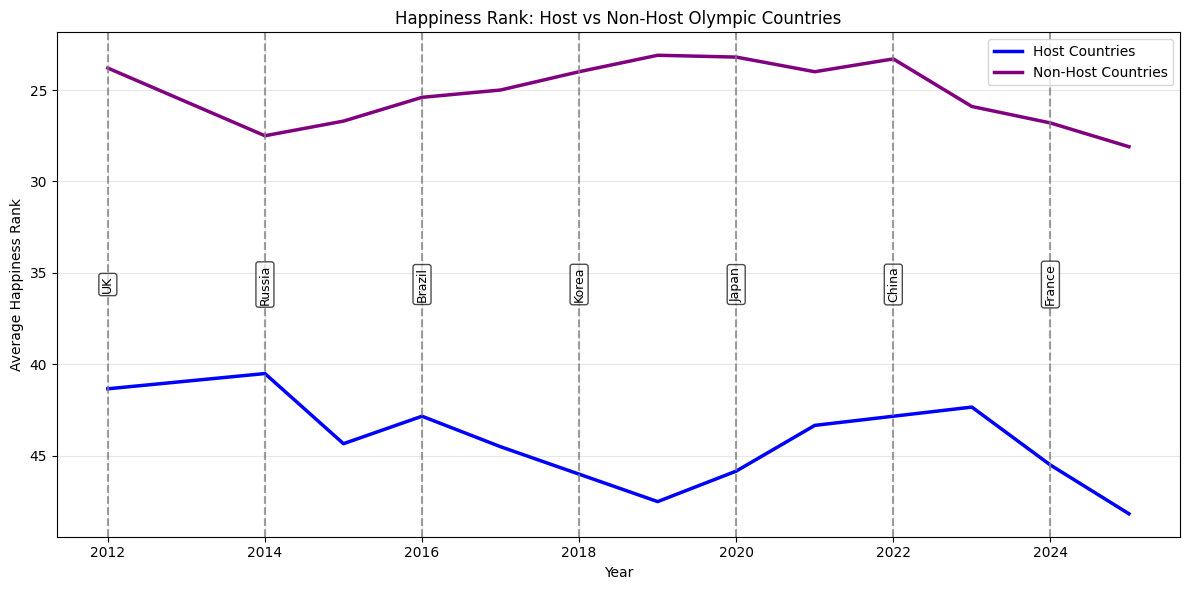

In [35]:

# Define host and non-host countries (based on Olympics 2012+)
host_countries = ['Brazil', 'China', 'France', 'Japan', 'Republic of Korea', 'United Kingdom']
non_host_countries = ['Australia', 'Austria', 'Canada', 'Germany', 'Greece', 'Italy', 'Mexico', 'Norway', 'Spain', 'United States']

# Filter and pivot data
filtered_df = happiness_df_2[
    (happiness_df_2['Country name'].isin(host_countries + non_host_countries)) & 
    (happiness_df_2['Year'] >= 2012)
]
pivot = filtered_df.pivot(index='Year', columns='Country name', values='Rank')

# Calculate averages
avg_host = pivot[host_countries].mean(axis=1)
avg_non_host = pivot[non_host_countries].mean(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(avg_host.index, avg_host, 'r-', linewidth=2.5, label='Host Countries', color = 'blue')
ax.plot(avg_non_host.index, avg_non_host, 'b-', linewidth=2.5, label='Non-Host Countries', color = 'purple')
ax.set_xlabel('Year')
ax.set_ylabel('Average Happiness Rank')
ax.set_title('Happiness Rank: Host vs Non-Host Olympic Countries')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.legend()
# Olympic host years (country: year)
olympic_hosts = {'UK': 2012, 'Russia': 2014, 'Brazil': 2016, 'Korea': 2018, 'Japan': 2020, 'China': 2022, 'France': 2024}
# Get y-axis limits
y_min, y_max = ax.get_ylim()
y_center = (y_min + y_max) / 2

# Add vertical lines with labels in the center
for country, year in olympic_hosts.items():
    if year in avg_host.index:
        ax.axvline(x=year, color='gray', linestyle='--', alpha=0.5)
        ax.text(year, y_center, country, rotation=90, ha='center', va='center', fontsize=9, 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
# Add vertical lines for Olympic years
olympic_years = {'Brazil': 2016, 'China': 2022, 'France': 2024, 'Japan': 2020, 
                 'Republic of Korea': 2018, 'Russia': 2014, 'United Kingdom': 2012}
for country, year in olympic_years.items():
    if year in avg_host.index:
        ax.axvline(x=year, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Plotting only a few Countires as drill down to see if another country is happier during the olympics if its not in their country

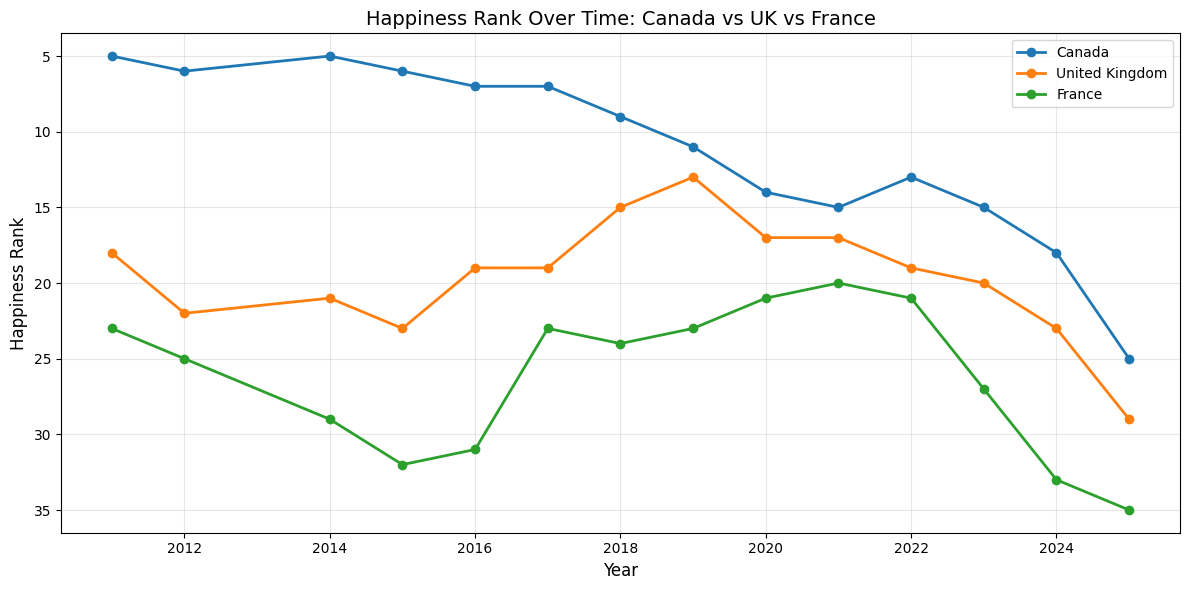

In [ ]:

# Filter for Canada, UK, and France
countries = ['Canada', 'United Kingdom', 'France']
filtered_df = happiness_df_2[happiness_df_2['Country name'].isin(countries)]

# Pivot the data
pivot_filtered = filtered_df.pivot(index='Year', columns='Country name', values='Rank')

# Define colors
color_map = {
    'Canada': '#1f77b4',      # blue
    'United Kingdom': '#ff7f0e', # orange
    'France': '#2ca02c'       # green
}

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

for country in countries:
    pivot_filtered[country].plot(ax=ax, marker='o', linewidth=2, 
                                  color=color_map[country], label=country)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Happiness Rank', fontsize=12)
ax.set_title('Happiness Rank Over Time: Canada vs UK vs France', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_yaxis()  # Lower rank = happier

plt.tight_layout()
plt.show()

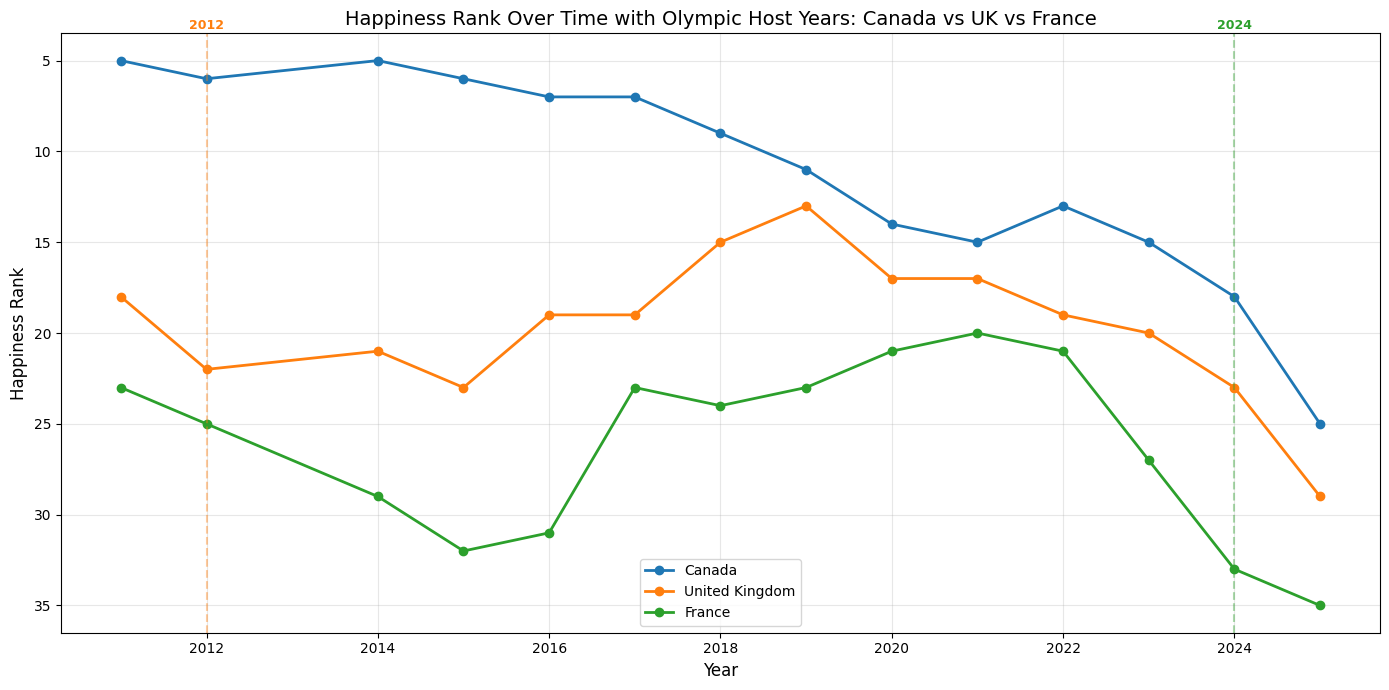

In [ ]:
# Filter for Canada, UK, and France
countries = ['Canada', 'United Kingdom', 'France']
filtered_df = happiness_df_2[happiness_df_2['Country name'].isin(countries)]

# Pivot the data
pivot_filtered = filtered_df.pivot(index='Year', columns='Country name', values='Rank')

# Define colors
color_map = {
    'Canada': '#1f77b4',      # blue
    'United Kingdom': '#ff7f0e', # orange
    'France': '#2ca02c'       # green
}

# Olympics hosted by each country with years
olympics = {
    'Canada': [1976, 1988, 2010],  # Montreal, Calgary, Vancouver
    'United Kingdom': [1908, 1948, 2012],  # London x3
    'France': [1900, 1924, 1968, 1992, 2024]  # Paris x2, Chamonix, Grenoble, Albertville, Paris 2024
}

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

for country in countries:
    pivot_filtered[country].plot(ax=ax, marker='o', linewidth=2, 
                                  color=color_map[country], label=country)

# Add vertical lines for Olympics
for country, years in olympics.items():
    color = color_map[country]
    for year in years:
        if year in pivot_filtered.index:  # Only add if year exists in data
            ax.axvline(x=year, color=color, linestyle='--', alpha=0.4, linewidth=1.5)
            # Add label above the line
            ax.text(year, ax.get_ylim()[0] * 0.98, f'{year}', 
                   ha='center', va='bottom', color=color, fontsize=9, fontweight='bold')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Happiness Rank', fontsize=12)
ax.set_title('Happiness Rank Over Time with Olympic Host Years: Canada vs UK vs France', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_yaxis()  # Lower rank = happier

plt.tight_layout()
plt.show()

Network Diagram for  all Countries